In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

In [2]:
df = pd.read_csv("out.csv", names=["a"])

In [3]:
df.head

<bound method NDFrame.head of               a
0     -3.447571
1      1.608477
2     -0.469808
3      0.131666
4      0.490572
...         ...
99995  1.763322
99996 -1.258574
99997  4.074084
99998  1.670164
99999  1.237674

[100000 rows x 1 columns]>

(array([2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00, 3.000e+00, 6.000e+00, 8.000e+00, 1.400e+01,
        8.000e+00, 1.700e+01, 1.600e+01, 2.800e+01, 3.400e+01, 4.800e+01,
        6.700e+01, 8.400e+01, 1.230e+02, 1.220e+02, 1.640e+02, 2.260e+02,
        2.480e+02, 3.170e+02, 3.520e+02, 4.170e+02, 4.800e+02, 5.860e+02,
        7.220e+02, 8.480e+02, 1.013e+03, 1.089e+03, 1.165e+03, 1.468e+03,
        1.577e+03, 1.854e+03, 1.917e+03, 2.169e+03, 2.259e+03, 2.428e+03,
        2.565e+03, 2.865e+03, 2.992e+03, 3.148e+03, 3.137e+03, 3.280e+03,
        3.450e+03, 3.426e+03, 3.405e+03, 3.572e+03, 3.520e+03, 3.591e+03,
        3.313e+03, 3.152e+03, 3.028e+03, 2.937e+03, 2.843e+03, 2.603e+03,
        2.410e+03, 2.259e+03, 2.099e+03, 1.925e+03, 1.705e+03, 1.573e+03,
        1.364e+03, 1.157e+03, 1.069e+03, 9.360e+02, 7.750e+02, 7.080e+02,
        6.110e+02, 5.100e+02, 3.860e+02, 3.600e+02, 2.800e+02, 2.210e+02,
        2.030e+02, 1.630e+02, 1.250e+0

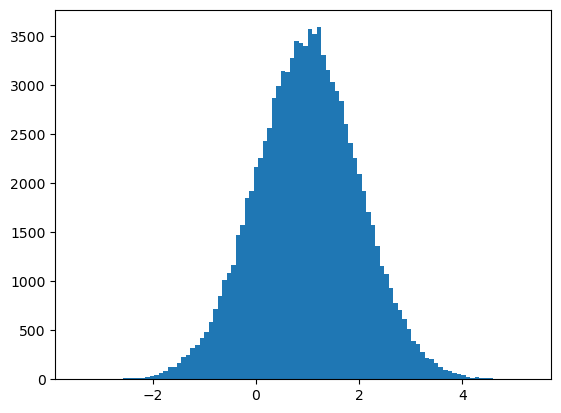

In [5]:
plt.hist(df, bins=100)

In [9]:


def loglog_hist(series: pd.Series, bins=50, **kwargs):
    """
    Plot a histogram of a pandas Series on a log-log scale with log-spaced bins.

    Parameters
    ----------
    series : pd.Series
        Input data. Only positive entries are used.
    bins : int or sequence, default=50
        If int, creates that many bins equally spaced on a logarithmic scale.
        If sequence, uses the given bin edges (assumed appropriate for log scale).
    **kwargs : additional keyword arguments
        Passed to matplotlib.pyplot.hist (e.g., alpha, color, edgecolor).

    Returns
    -------
    None
        Displays the plot.
    """
    # Drop missing values
    data = series.dropna()

    # Keep only positive values (log scale requires x > 0)
    positive_data = data[data > 0]
    if len(positive_data) < len(data):
        warnings.warn(f"Dropped {len(data) - len(positive_data)} non-positive values "
                      f"({len(positive_data)} remain)")

    if len(positive_data) == 0:
        raise ValueError("No positive data points left after filtering. Cannot plot log-log histogram.")

    # Determine bin edges
    if isinstance(bins, int):
        # Create bins equally spaced on a logarithmic scale
        log_min = np.log10(positive_data.min())
        log_max = np.log10(positive_data.max())
        bin_edges = np.logspace(log_min, log_max, bins + 1)
    else:
        # Use user-supplied bins (assumed suitable for log scale)
        bin_edges = bins

    # Plot histogram with log-spaced bins (linear counts)
    plt.hist(positive_data, bins=bin_edges, **kwargs)

    # Set both axes to logarithmic scale
    plt.xscale('log')
    plt.yscale('log')

    # Labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram (log-log scale with log-spaced bins)')

    plt.show()

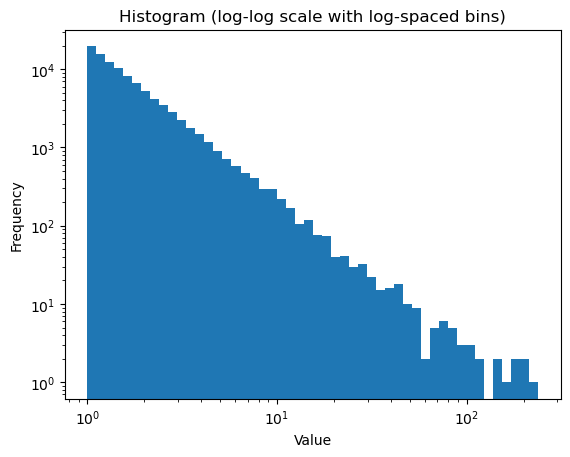

In [17]:
loglog_hist(df.a)